# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.

In [4]:


import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt




In [5]:



# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage =  pd.read_csv('/datasets/usage.csv')




In [6]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:


# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)




plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---
## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
# cantidad de nulos para users


print(users.isna().sum())
print(users.isna().mean())



user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [14]:




# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())





id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64




✍️ **Comentario**: Diagnostico de valores nulos  

**Dataset: users**

city (11.7%) - Nivel medio de nulos.
Imputar con “Unknown” 

churn_date (88.8%) - Nivel muy alto de nulos.
No eliminar, ya que es un nulo estructural ya que indica los usuarios activos. Convertir en variable binaria (0/1)

**Dataset: usage**

date (0.12%) - Nivel muy bajo de nulos.
Eliminar registros. 

duration (55.2%) - Alto nivel de nulos.
No imputar y tampoco eliminar.

length (44.7%) - Alto nivel de nulos.
No imputar y tampoco eliminar.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
print(users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` valores dentro de un rango consistente (10000–13999)
- La columna `age` se observa un valor mínimo de -999, lo cual es inválido

In [16]:
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` rangos consistentes, sin anomalías.
- La columna `duration` valores entre 0 y 120. El 0 puede ser válido o indicar registros sin llamada.
- La columna `length` valores entre 0 y 1490. Valores altos pueden ser normales en mensajes largos.

In [17]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nColumna: {col}")
    print(users[col].value_counts(dropna=False))




Columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` presenta valores nulos (469) y un valor inconsistente "?" (96)
- La columna `plan` presenta dos categorías (Basico y Premium) bien definidas y sin nulos.

In [18]:


# explorar columna categórica de usage

usage['type'] 
print("\nColumna: type")
print(usage['type'].value_counts(dropna=False))





Columna: type
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` contiene (text y call) bien definidas y sin nulos.


---
✍️ **Comentario**: Diagnostico valores inválidos o sentinels

**Columna city**: Se encontró el valor "?", que representa un dato desconocido.
Reemplazar "?" por NaN e imputar como "Unknown".

**Columna plan** Contiene categorías válidas (Basico, Premium) sin valores inconsistentes.
No requiere limpieza.

**Columna type** Contiene valores válidos (call, text) consistentes con el negocio.
No requiere limpieza.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users


users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print(users['reg_date'].dtype)



datetime64[ns]


In [20]:
# Convertir a fecha la columna `date` de usage


usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print(usage['date'].dtype)



datetime64[ns]


In [21]:
# Revisar los años presentes en `reg_date` de users



users['year'] = users['reg_date'].dt.year
print("Años en users (reg_date):")
print(users['year'].value_counts(dropna=False).sort_index())




Años en users (reg_date):
2022    1314
2023    1316
2024    1330
2026      40
Name: year, dtype: int64


En `reg_date`, se observan fechas entre 2022 y 2024, lo cual es consistente con el periodo de análisis. Sin embargo, aparecen 40 registros en 2026, lo cual es un año futuro e inválido.

In [24]:

# Revisar los años presentes en `date` de usage


usage['year'] = usage['date'].dt.year
print("\nAños en usage (date):")
print(usage['year'].value_counts(dropna=False).sort_index())





Años en usage (date):
2024.0    39950
NaN          50
Name: year, dtype: int64


En `date`,se observan unicamente registros del año 2024 y 50 valores en NaN que son fechas invalidas.

✍️ **Comentario**: Diagnostico fechas fuera de rango

**En reg_date**  aparecen 40 registros en 2026, lo cual es un año futuro e inválido.
Tratar estos registros como error, eliminarlos o corregirlos si es posible.

**En date** Se identifican 50 valores NaN, que provienen de fechas inválidas.
 Eliminar estos registros, ya que representan una proporción muy baja y no afectan el análisis.

---
## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [25]:




# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()






count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city



users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))




Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [27]:
# Marcar fechas futuras como NA para reg_date


users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))



2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:


# Verificación MAR en usage (Missing At Random) para duration

print("Nulos en duration por type:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))




Nulos en duration por type:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [29]:

# Verificación MAR en usage (Missing At Random) para length

print("\nNulos en length por type:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))




Nulos en length por type:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Nulos en `duration` se concentran en el type text, los nulos dependen de la variable type, por lo que son MAR en función del tipo de uso
Nulos en `length` se concentran en el type call son MAR, ya que dependen directamente del tipo de servicio.


---
## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [30]:

# Columnas auxiliares



usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)




,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Renombrar columnas



usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)




,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:



# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)




,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [33]:


# Resumen estadístico de las columnas numéricas

cols_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("Resumen estadístico:")
print(user_profile[cols_numericas].describe())




Resumen estadístico:
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [34]:


# Distribución porcentual del tipo de plan
print("\nDistribución porcentual del plan:")
print(user_profile['plan'].value_counts(normalize=True) * 100)





Distribución porcentual del plan:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---
## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 


Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


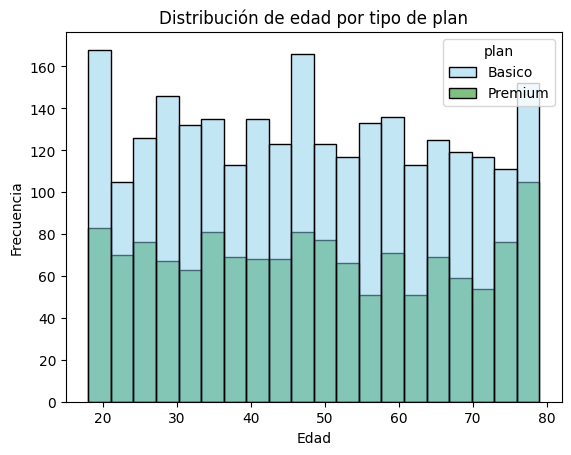

In [35]:
# Histograma para visualizar la edad (age)


sns.histplot(data=user_profile, x='age', hue='plan', bins=20, palette=['skyblue','green'])
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()





💡Insights: 
- **Distribución Uniforme**: La edad no parece ser un factor determinante para elegir entre el plan Básico y el Premium. Ambos planes muestran una distribución relativamente constante a lo largo de todos los rangos de edad desde los 18 hasta los 80 años, sin sesgos marcados hacia jóvenes o adultos mayores.

**Preferencia General por el Plan Básico**: En casi todos los rangos de edad, la frecuencia del Plan Básico es superior a la del Plan Premium. Esto indica que el plan básico es la opción preferida de los usuarios.


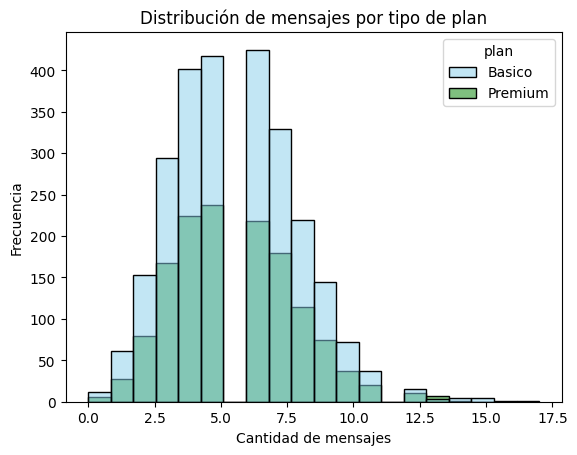

In [36]:
# Histograma para visualizar la cant_mensajes


sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=20, palette=['skyblue','green'])
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- **Comportamiento de Uso Similar**: Ambos grupos Básico y Premium muestran una distribución de mensajes muy parecida, siguiendo una forma de campana distribución normal con un pico claro entre los 4 y 7 mensajes. Esto sugiere que el volumen de mensajería no es el factor que diferencia a los clientes de un plan u otro. Presentando outliers a partir de los 12 mensajes en donde la frecuencia cae drásticamente para ambos planes. El uso de mensajería es muy moderado en toda la base de datos, con muy pocos usuarios superando los 15 mensajes, independientemente por su plan.

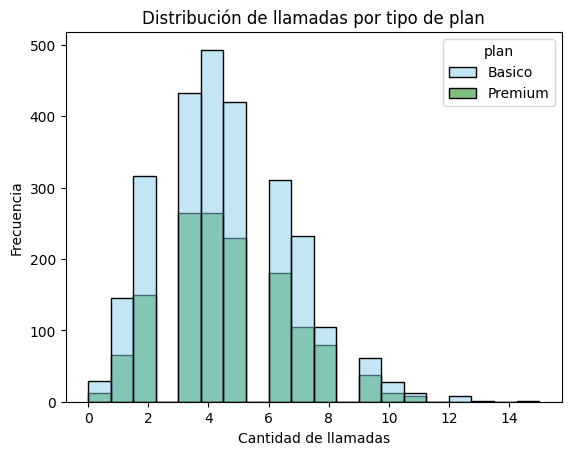

In [37]:

# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=20, palette=['skyblue','green'])
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()




💡Insights: 
- Distribución en donde se inclina la cola hacia la derecha y trata de ser normal en donde los clientes usan el servicio de forma moderada independientemente del plan. Los usuarios en la cola de la derecha son datos atipicos.

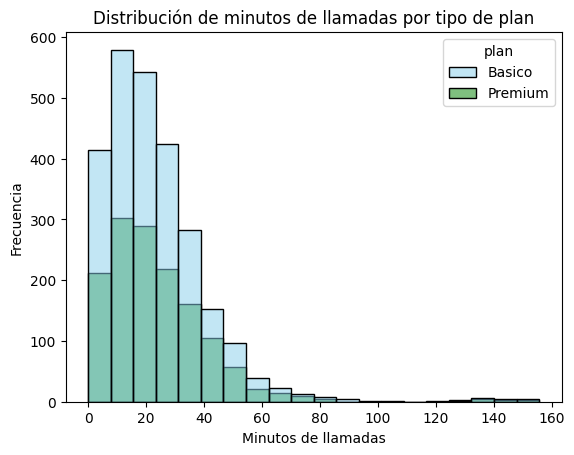

In [38]:

# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=20, palette=['skyblue','green'])
plt.title('Distribución de minutos de llamadas por tipo de plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()




💡Insights: 
- Distribución con un sesgo a la derecha muy pronunciado. La gran mayoría de los usuarios consumen entre 10 y 30 minutos, pero la cola se extiende hasta superar los 150 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

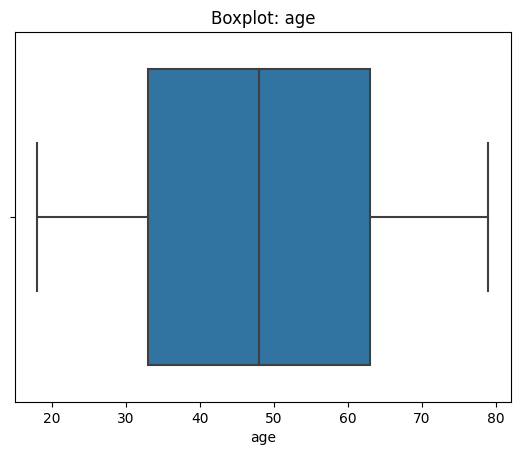

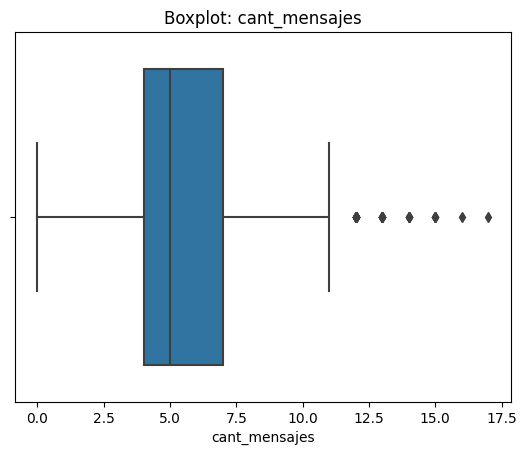

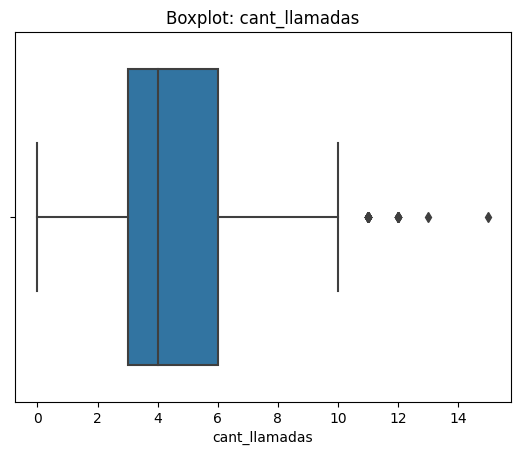

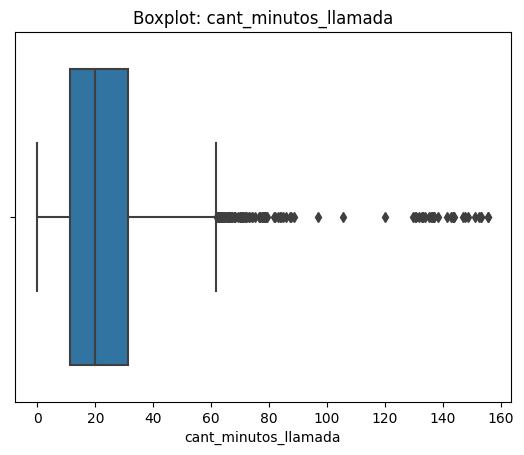

In [39]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()



💡Insights: 
- **Age**: No presenta outliers
- **cant_mensajes**: Presenta outliers significativos a la derecha. Se observan varios puntos a partir de los 11 mensajes aproximadamente. El valor máximo llega hasta 17, lo cual queda muy lejos del límite superior del bigote.
- **cant_llamadas**:Presenta pocos outliers a la derecha. Hay un grupo pequeño de usuarios que realizan entre 11 y 15 llamadas.
- **cant_minutos_llamada**: Es la variable con mayor cantidad de outliers. Se observa una línea casi continua de puntos (valores atípicos) que comienza cerca de los 60 minutos y se extiende hasta superar los 150.

In [40]:



# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"\n {col}")
    print(f"Límite superior: {limite_superior}"
)





 cant_mensajes
Límite superior: 11.5

 cant_llamadas
Límite superior: 10.5

 cant_minutos_llamada
Límite superior: 61.8575


In [41]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes**: mantener ya que esta es la variabilidad de los usuarios. 
- **cant_llamadas**: mantener ya que es el comportamiento esperado y no es extremo.
- **cant_minutos_llamada**: mantener ya que son los datos claves del plan premium.

---
## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [42]:


# Crear columna grupo_uso

user_profile['grupo_uso'] = 'Alto uso'  

user_profile.loc[
    (user_profile['cant_llamadas'] < 5) & 
    (user_profile['cant_mensajes'] < 5),'grupo_uso'] = 'Bajo uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 10) & 
    (user_profile['cant_mensajes'] < 10) &
    (user_profile['grupo_uso'] != 'Bajo uso'),
    'grupo_uso'] = 'Uso medio'

user_profile['grupo_uso'].value_counts()


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [43]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:

# Crear columna grupo_edad

user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

user_profile.loc[
    (user_profile['age'] < 60) & (user_profile['grupo_edad'] != 'Joven'),'grupo_edad'] = 'Adulto'

user_profile ['grupo_edad'].value_counts()



Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [45]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor



### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


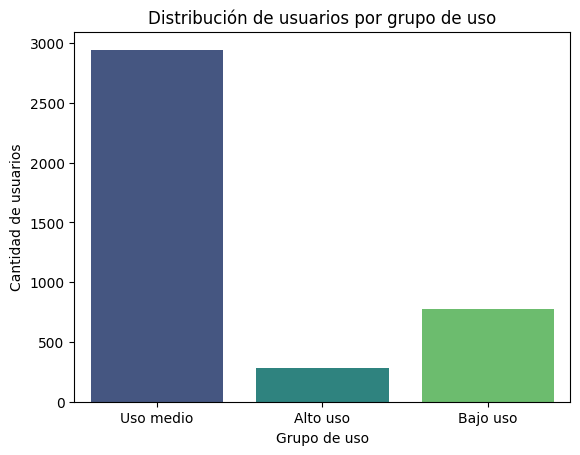

In [46]:
# Visualización de los segmentos por uso



sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()




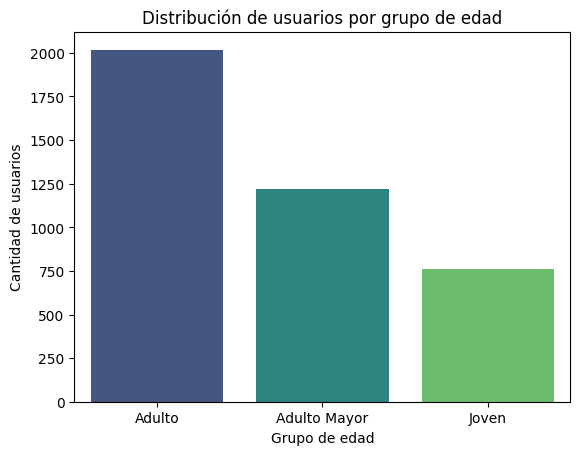

In [47]:



sns.countplot(data=user_profile, x='grupo_edad', palette='viridis')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- **Inconsistencia de registros**: Se identificó una diferencia de 1 registro entre métricas de consumo y usuarios (3,999 vs 4,000), equivalente al 0.025% de la muestra.
Impacto: Bajo, no afecta el análisis, pero evidencia oportunidades de mejora en integración de datos.
- **Valores inválidos y sentinels**:
age = -999 reemplazado por la mediana.
city = "?" tratado como valor faltante.
- **Valores nulos estructurales**:
duration y length presentan altos nulos, pero se determinó que dependen del tipo de servicio call vs text.
Impacto: No son errores, se mantuvieron para preservar la lógica del negocio.
- **Fechas inválidas**
Registros en años futuros (2026) y valores inválidos.
- **Sesgo por outliers**:
Las variables de consumo presentan asimetría a la derecha, donde pocos usuarios intensivos elevan el promedio
Impacto: El promedio no representa al usuario típico; la mediana es más adecuada.

🔍 **Segmentos por Edad**
- Predominan los usuarios Adultos (30–59 años), seguidos por jóvenes.
- Los adultos mayores representan una menor proporción.


📊 **Segmentos por Nivel de Uso**
- La mayoría de los usuarios se concentra en bajo y medio uso.
- Existe un grupo reducido de alto uso con alto consumo, especialmente en minutos de llamadas.

➡️ Esto sugiere que el consumo está desbalanceado, con una minoría generando gran parte del uso.
Los planes actuales podrían no estar completamente alineados con el comportamiento real de los clientes.
Existe una oportunidad clara de segmentación basada en comportamiento y perfil demográfico si se contara con dicha información .


💡 **Recomendaciones**
- Diseñar planes diferenciados para usuarios de alto consumo, especialmente enfocados en minutos de llamadas.
- Crear planes optimizados para usuarios de bajo consumo, evitando sobrecostos y mejorando la satisfacción.
- Implementar estrategias comerciales, migrando usuarios de uso medio a planes más adecuados a su consumo real.
- Desarrollar ofertas segmentadas por edad, considerando posibles diferencias en hábitos de uso.
- Monitorear continuamente outliers, ya que pueden representar oportunidades de negocio o alertas de comportamiento atípico.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`